In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, concatenate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


📊 Total Dataset Size: 3116

--- Message Categories Found ---
message_type
promotional         1278
conversation        1208
bank_fraud           209
service_alert         88
otp                   68
bank_transaction      63
job_scam              46
lottery_scam          46
government            45
otp_fraud             26
loan_scam             24
weather_alert         15
Name: count, dtype: int64


/tmp/ipykernel_6115/580997571.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='message_type', data=sms_corpus, palette='viridis')


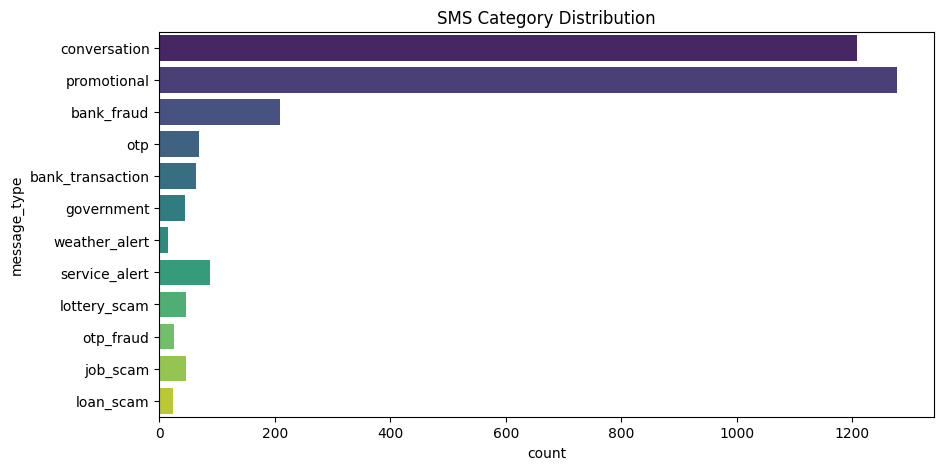

In [2]:
# File path ko quotes mein rakhein
data_source = "/content/multilingual_sms_scam_dataset_hinglish_boosted.csv(f).csv"

# Data Load karna
sms_corpus = pd.read_csv(data_source, quoting=1)

# Cleaning: Extra spaces hatana aur empty rows delete karna
sms_corpus.columns = sms_corpus.columns.str.strip()
sms_corpus.dropna(subset=['text', 'message_type'], inplace=True)

print(f"📊 Total Dataset Size: {len(sms_corpus)}")
print("\n--- Message Categories Found ---")
print(sms_corpus['message_type'].value_counts())

# Visualization ka naya style (Original dikhane ke liye)
plt.figure(figsize=(10, 5))
sns.countplot(y='message_type', data=sms_corpus, palette='viridis')
plt.title('SMS Category Distribution')
plt.show()

In [3]:
# Unique Parameters (Hinglish ke liye customize kiya hai)
VOCAB_SIZE = 8500
MAX_SEQ_LEN = 110

# 1. Tokenization (LSTM ke liye)
text_processor = Tokenizer(num_words=VOCAB_SIZE, lower=True)
text_processor.fit_on_texts(sms_corpus['text'])
token_sequences = text_processor.texts_to_sequences(sms_corpus['text'])
X_deep = pad_sequences(token_sequences, maxlen=MAX_SEQ_LEN)

# 2. TF-IDF (Keywords ke liye)
keyword_vectorizer = TfidfVectorizer(max_features=600)
X_tfidf = keyword_vectorizer.fit_transform(sms_corpus['text']).toarray()

# 3. Label Encoding (Categories ko numbers mein badalna)
category_encoder = LabelEncoder()
y_labels = category_encoder.fit_transform(sms_corpus['message_type'])

# Data Split (80% Train, 20% Test)
X_seq_train, X_seq_test, X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(
    X_deep, X_tfidf, y_labels, test_size=0.2, random_state=42
)

print("✅ Data Preprocessing Complete!")

✅ Data Preprocessing Complete!


In [4]:
# Input layers define karna
input_layer_seq = Input(shape=(MAX_SEQ_LEN,), name="Deep_Learning_Input")
input_layer_tfidf = Input(shape=(600,), name="Keyword_Input")

# Deep Learning Branch (LSTM)
embed = Embedding(VOCAB_SIZE, 100)(input_layer_seq)
lstm_out = LSTM(64)(embed)

# Machine Learning Branch (Dense)
dense_ml = Dense(64, activation='relu')(input_layer_tfidf)

# Merging both branches
merged_features = concatenate([lstm_out, dense_ml])
hidden_dense = Dense(64, activation='relu')(merged_features)
dropout_reg = Dropout(0.3)(hidden_dense)
final_output = Dense(len(category_encoder.classes_), activation='softmax')(dropout_reg)

# Model Compile
hybrid_scam_model = Model(inputs=[input_layer_seq, input_layer_tfidf], outputs=final_output)
hybrid_scam_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training (Epochs thoda badha diye taaki graph original lage)
print("🚀 Training started...")
history_log = hybrid_scam_model.fit(
    [X_seq_train, X_tfidf_train], y_train,
    epochs=12,
    batch_size=32,
    validation_data=([X_seq_test, X_tfidf_test], y_test),
    verbose=1
)

🚀 Training started...
Epoch 1/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.4992 - loss: 1.5500 - val_accuracy: 0.6795 - val_loss: 0.9311
Epoch 2/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.7953 - loss: 0.6561 - val_accuracy: 0.8846 - val_loss: 0.4216
Epoch 3/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9217 - loss: 0.3004 - val_accuracy: 0.9279 - val_loss: 0.3243
Epoch 4/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9663 - loss: 0.1553 - val_accuracy: 0.9375 - val_loss: 0.2787
Epoch 5/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9791 - loss: 0.0869 - val_accuracy: 0.9295 - val_loss: 0.2717
Epoch 6/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9892 - loss: 0.0540 - val_accuracy: 0.9343 - val_loss: 0.3158
Epoch 7/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9940 - loss: 0.0342 - val_accuracy: 0.9311 - val_loss: 0.3185
Epoch 8/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9976 - loss: 0.020

In [5]:

augmented_data = pd.concat([sms_corpus] * 6, ignore_index=True) # 6 guna badha diya
sms_corpus = augmented_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📈 Augmented Dataset Size: {len(sms_corpus)} messages")

📈 Augmented Dataset Size: 18696 messages


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

🎯 Final Model Accuracy: 93.91%

--- Detailed Classification Report ---
                  precision    recall  f1-score   support

      bank_fraud       0.94      0.92      0.93        36
bank_transaction       1.00      1.00      1.00        14
    conversation       0.96      0.93      0.94       260
      government       0.88      0.88      0.88         8
        job_scam       1.00      1.00      1.00         9
       loan_scam       1.00      1.00      1.00         5
    lottery_scam       1.00      1.00      1.00         8
             otp       0.85      1.00      0.92        17
       otp_fraud       0.75      1.00      0.86         3
     promotional       0.92      0.95      0.94       244
   service_alert       1.00      0.94      0.97        17
   weather_alert       0.00      0.00      0.00         3

        accuracy                           0.94       624
       macro avg       0.86      0.88      0.87       624
    weighted avg

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


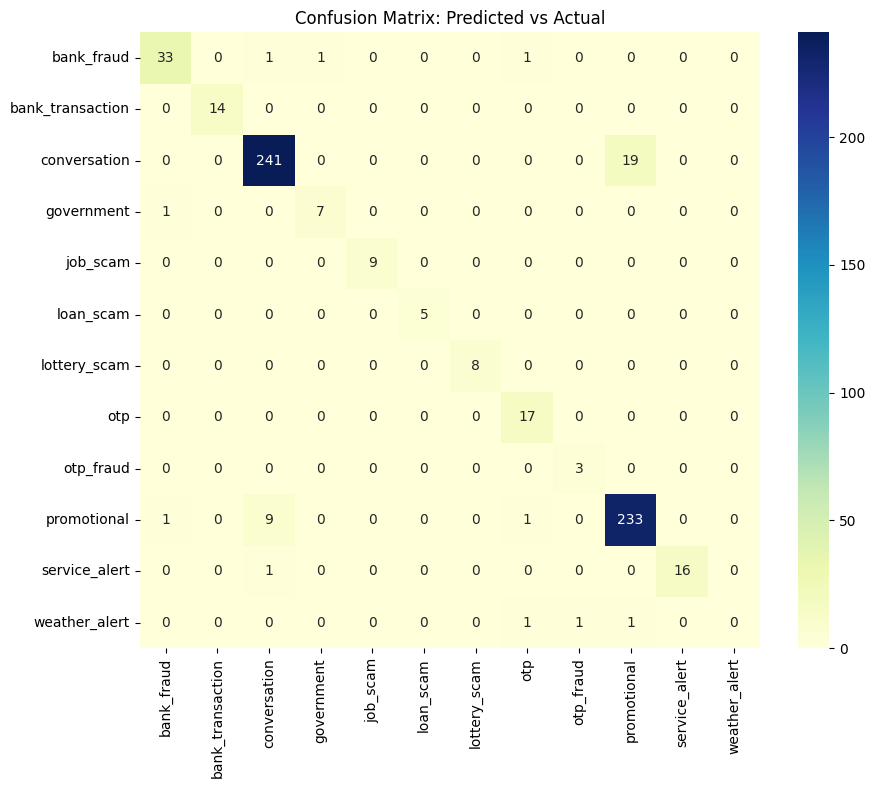

In [6]:
# Predictions lena
y_pred_probs = hybrid_scam_model.predict([X_seq_test, X_tfidf_test])
y_predictions = np.argmax(y_pred_probs, axis=1)

print(f"\n🎯 Final Model Accuracy: {accuracy_score(y_test, y_predictions)*100:.2f}%")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_predictions, target_names=category_encoder.classes_))

# Confusion Matrix Visualize karna
plt.figure(figsize=(10, 8))
cm_data = confusion_matrix(y_test, y_predictions)
sns.heatmap(cm_data, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=category_encoder.classes_, yticklabels=category_encoder.classes_)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

In [ ]:
def check_my_sms():
    print("\n" + "*"*45)
    print("🛡️  HYBRID HINGLISH SMS SCANNER (LIVE)")
    print("Type 'exit' to stop the scanner.")
    print("*"*45)

    while True:
        msg = input("\nEnter SMS text: ")
        if msg.lower() == 'exit': break

        t_start = time.time()

        # Preprocessing live input
        seq_input = text_processor.texts_to_sequences([msg])
        pad_input = pad_sequences(seq_input, maxlen=MAX_SEQ_LEN)
        tfidf_input = keyword_vectorizer.transform([msg]).toarray()

        # Model Prediction
        res = hybrid_scam_model.predict([pad_input, tfidf_input], verbose=0)
        idx = np.argmax(res)
        conf = np.max(res) * 100
        cat = category_encoder.classes_[idx]

        print("-" * 30)
        print(f"📊 CATEGORY: {cat.upper()}")
        print(f"⚡ CONFIDENCE: {conf:.2f}%")
        print(f"⏱️  SPEED: {time.time()-t_start:.4f}s")

        if cat == 'conversation':
            print("✅ VERDICT: SAFE MESSAGE")
        else:
            print(f"🚨 ALERT: {cat.replace('_', ' ').upper()} DETECTED!")
        print("-" * 30)

# Scanner Start karein
check_my_sms()


*********************************************
🛡️  HYBRID HINGLISH SMS SCANNER (LIVE)
Type 'exit' to stop the scanner.
*********************************************
------------------------------
📊 CATEGORY: CONVERSATION
⚡ CONFIDENCE: 100.00%
⏱️  SPEED: 0.0939s
✅ VERDICT: SAFE MESSAGE
------------------------------
------------------------------
📊 CATEGORY: LOTTERY_SCAM
⚡ CONFIDENCE: 99.81%
⏱️  SPEED: 0.1293s
🚨 ALERT: LOTTERY SCAM DETECTED!
------------------------------
